Test the camera projection method in the control simulation pipeline

In [1]:
import sys
sys.path.insert(1, 'E:/OneDrive - UC San Diego/UCSD/Lab/Catheter/diff_catheter/scripts')

import cv2
import matplotlib.pyplot as plt

from utils import *
import camera_settings

In [2]:
path = "E:/OneDrive - UC San Diego/UCSD/Lab/Catheter/diff_catheter/data/target_parameters"
target_name = "target_0"
image_save_path = path + '/' + target_name + '.png'
params_save_path = path + '/' + target_name + '.npy'

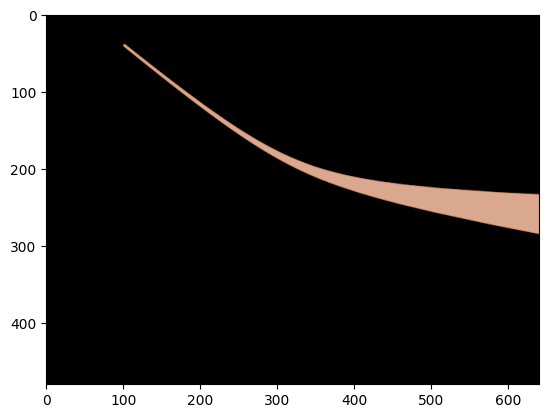

In [3]:
image = cv2.imread(image_save_path)
plt.imshow(image)

In [4]:
def convert_3d_to_2d(p, camera_extrinsics, fx, fy, cx, cy):
    """
    Convert 3D points to 2D points
    """ 
    p_4d = np.append(p, 1)
    p_cam = camera_extrinsics @ p_4d
    p_x = p_cam[0] * fx / (-p_cam[2]) + cx
    p_y = p_cam[1] * fy / (-p_cam[2]) + cy
    p_2d = np.array([p_x, p_y])
    
    # p_2d[0] = round(640 - p_2d[0])
    p_2d[0] = round(p_2d[0])
    p_2d[1] = round(480 - p_2d[1])
    # p_2d[1] = round(p_2d[1])
    
    return p_2d

In [5]:
para_gt = read_gt_params(params_save_path)
tip_3d = para_gt[-3:]
tip_2d = convert_3d_to_2d(tip_3d, camera_settings.extrinsics, camera_settings.a, camera_settings.b, camera_settings.center_x, camera_settings.center_y)
print(tip_2d)

[102.  41.]


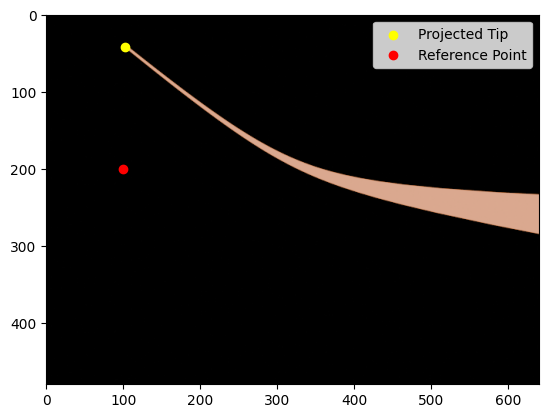

In [6]:
plt.imshow(image)
plt.scatter(tip_2d[0], tip_2d[1], color='yellow', label='Projected Tip')
plt.scatter(100, 200, color='red', label='Reference Point')
plt.legend()

In [7]:
def bezier_curve_2d(P0, P1, P2, num_points=100):
    """
    Compute points on a 2D quadratic Bezier curve
    
    Parameters:
    P0, P1, P2: Control points of the Bezier curve (array-like, 2D coordinates)
    num_points: Number of points to generate on the Bezier curve (default 100)
    
    Returns:
    bezier_points: Numpy array of points on the Bezier curve
    """
    # Define the function to compute a point on the Bezier curve for a given t
    def bezier_curve(t, P0, P1, P2):
        return (1 - t)**2 * P0 + 2 * (1 - t) * t * P1 + t**2 * P2
    
    # Generate t values
    t_values = np.linspace(0, 1, num_points)
    
    # Compute all points on the Bezier curve
    bezier_points = np.array([bezier_curve(t, P0, P1, P2) for t in t_values])
    
    return bezier_points

[-0.2310447  -0.21116728  0.93573913]
[ 0.01633641 -0.00111083  0.52413419]
(100, 3)


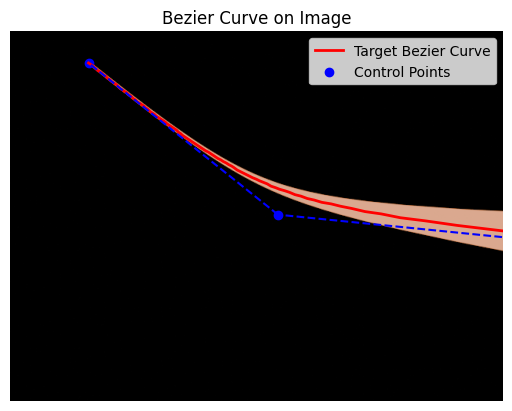

In [8]:
para_gt = read_gt_params(params_save_path)
p2_3d = para_gt[-3:]
p1_3d = para_gt[:3]
p0_3d = np.array([2e-2, 2e-3, 0.00001])

print(p2_3d)
print(p1_3d)

control_points = np.vstack([p0_3d, p1_3d, p2_3d])

bezier_3d = bezier_curve_3d(control_points)

print(bezier_3d.shape)

bezier_2d = np.zeros((bezier_3d.shape[0], 2))
for i in range(bezier_3d.shape[0]):
    bezier_2d[i] = convert_3d_to_2d(bezier_3d[i], camera_settings.extrinsics, camera_settings.a, camera_settings.b, camera_settings.center_x, camera_settings.center_y)
    
p2_2d = convert_3d_to_2d(p2_3d, camera_settings.extrinsics, camera_settings.a, camera_settings.b, camera_settings.center_x, camera_settings.center_y)
p1_2d = convert_3d_to_2d(p1_3d, camera_settings.extrinsics, camera_settings.a, camera_settings.b, camera_settings.center_x, camera_settings.center_y)
p0_2d = convert_3d_to_2d(p0_3d, camera_settings.extrinsics, camera_settings.a, camera_settings.b, camera_settings.center_x, camera_settings.center_y)
    
bezier_points = bezier_2d[1:, :]
# bezier_points = bezier_2d

plt.imshow(image)

# 在图片上绘制贝塞尔曲线
plt.plot(bezier_points[:, 0], bezier_points[:, 1], color='red', linewidth=2, label='Target Bezier Curve')

# 绘制控制点
plt.scatter([p0_2d[0], p1_2d[0], p2_2d[0]], [p0_2d[1], p1_2d[1], p2_2d[1]], color='blue', label='Control Points')
# Connect control points with dashed lines (P0 to P1, P1 to P2)
plt.plot([p0_2d[0], p1_2d[0]], [p0_2d[1], p1_2d[1]], linestyle='--', color='blue')
plt.plot([p1_2d[0], p2_2d[0]], [p1_2d[1], p2_2d[1]], linestyle='--', color='blue')

# Set the axis limits to match the image size
plt.xlim(0, 640)  # X axis limit for image width
plt.ylim(480, 0)  # Y axis limit for image height, inverted to match image coordinates

# 显示最终结果
plt.title("Bezier Curve on Image")
plt.axis('off')  # 关闭坐标轴
plt.legend()
plt.show()



